## DEEP NEURAL NETWORKS - ASSIGNMENT 3: RNN vs TRANSFORMER FOR TIME SERIES
Recurrent Neural Networks vs Transformers for Time Series Prediction


### STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

**BITS ID:** 2025AE05076 <br>
**Name:** Ajit Mario John <br>
**Email:** 2025AE05076@wilp.bits-pilani.ac.in <br>
**Date:** 2026-05-03 <br>

## ASSIGNMENT OVERVIEW

Implements and compares two time series forecasting approaches:
1. LSTM (2 stacked layers) using PyTorch
2. Transformer Encoder with sinusoidal positional encoding using PyTorch

Dataset : Daily Delhi Climate (Weather Data)
Target  : Predict mean temperature (meantemp) 1 step ahead
Features: meantemp, humidity, wind_speed, meanpressure (multivariate)

CRITICAL REQUIREMENTS MET:
- Positional encoding: sinusoidal (mandatory)
- Multi-head attention: torch.nn.TransformerEncoder with nhead=4
- NO pre-trained transformers (HuggingFace / TimeGPT)
- Temporal train/test split (NO shuffling)
- LSTM has >= 2 stacked layers


In [1]:
# ============================================================
# Import Required Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import json
import os
import math
import platform
import sys
from datetime import datetime

In [2]:
# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


### PART 1: DATASET LOADING AND EXPLORATION

In [4]:
# 1.1 Required metadata fields
dataset_name        = "Daily Delhi Climate"
dataset_source      = "Kaggle - Sumanthvrao (sumanthvrao/daily-climate-time-series-data)"
n_features          = 4          # meantemp, humidity, wind_speed, meanpressure
sequence_length     = 30         # lookback window (within 10-50 requirement)
prediction_horizon  = 1          # 1 step ahead (within 1-10 requirement)
problem_type        = "time_series_forecasting"
target_feature      = "meantemp" # column index 0

In [5]:
primary_metric      = "RMSE"
metric_justification = (
    "RMSE is chosen as the primary metric because temperature forecasting errors that "
    "are large (e.g., off by 5°C vs 1°C) are disproportionately more impactful. RMSE "
    "penalises large errors more heavily than MAE, making it appropriate for this task."
)

In [6]:
# 1.2 Download dataset if not present locally, then load
def download_weather(data_path="data/weather/DailyDelhiClimateTrain.csv"):
    if os.path.exists(data_path):
        print(f"Dataset found at '{data_path}' — skipping download.")
        return
    print("Dataset not found locally. Downloading from Kaggle...")
    os.makedirs("data/weather", exist_ok=True)

    # Install kaggle into the active interpreter if missing
    try:
        import kaggle
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, "-m", "pip", "install", "kaggle", "-q"])
        import kaggle

    try:
        kaggle.api.authenticate()
        kaggle.api.dataset_download_files(
            "sumanthvrao/daily-climate-time-series-data",
            path="data/weather/",
            unzip=True,
        )
        print("Download complete.")
    except Exception as e:
        print(f"Kaggle download failed: {e}")
        print("Ensure kaggle.json is placed at ~/.kaggle/kaggle.json")
        print("Then re-run this cell.")
        raise

In [7]:
download_weather()

Dataset found at 'data/weather/DailyDelhiClimateTrain.csv' — skipping download.


In [8]:
train_csv_path = "data/weather/DailyDelhiClimateTrain.csv"
test_csv_path  = "data/weather/DailyDelhiClimateTest.csv"

In [9]:
df_train_raw = pd.read_csv(train_csv_path, parse_dates=["date"])
df_test_raw  = pd.read_csv(test_csv_path,  parse_dates=["date"])

In [10]:
df_all = pd.concat([df_train_raw, df_test_raw], ignore_index=True)
df_all = df_all.sort_values("date").reset_index(drop=True)

In [11]:
feature_cols = ["meantemp", "humidity", "wind_speed", "meanpressure"]
data_array   = df_all[feature_cols].values.astype(np.float32)

In [12]:
n_samples = len(data_array)   # 1576

In [13]:
print("\n" + "=" * 70)
print("DATASET INFORMATION")
print(f"Dataset:            {dataset_name}")
print(f"Source:             {dataset_source}")
print(f"Total Samples:      {n_samples}")
print(f"Number of Features: {n_features}  {feature_cols}")
print(f"Target Feature:     {target_feature}")
print(f"Sequence Length:    {sequence_length}")
print(f"Prediction Horizon: {prediction_horizon}")
print(f"Primary Metric:     {primary_metric}")
print(f"Justification:      {metric_justification}")
print(f"Date Range:         {df_all['date'].iloc[0].date()} → {df_all['date'].iloc[-1].date()}")


DATASET INFORMATION
Dataset:            Daily Delhi Climate
Source:             Kaggle - Sumanthvrao (sumanthvrao/daily-climate-time-series-data)
Total Samples:      1576
Number of Features: 4  ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
Target Feature:     meantemp
Sequence Length:    30
Prediction Horizon: 1
Primary Metric:     RMSE
Justification:      RMSE is chosen as the primary metric because temperature forecasting errors that are large (e.g., off by 5°C vs 1°C) are disproportionately more impactful. RMSE penalises large errors more heavily than MAE, making it appropriate for this task.
Date Range:         2013-01-01 → 2017-04-24


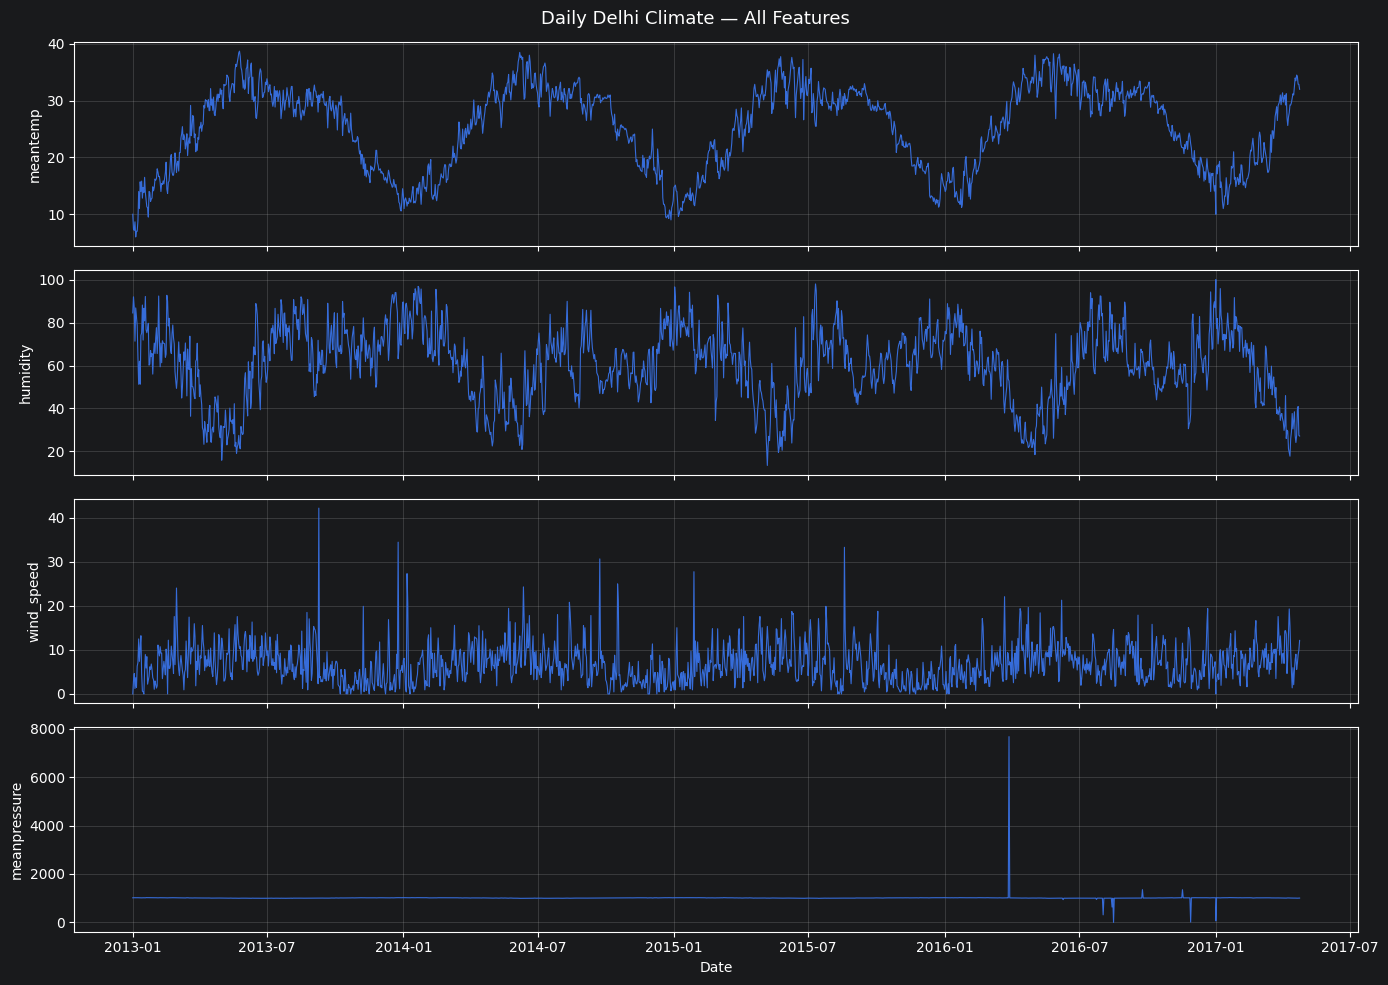

In [14]:
# 1.3 Time series plots
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for i, col in enumerate(feature_cols):
    axes[i].plot(df_all["date"], df_all[col], linewidth=0.8)
    axes[i].set_ylabel(col)
    axes[i].grid(True, alpha=0.3)
axes[-1].set_xlabel("Date")
plt.suptitle("Daily Delhi Climate — All Features", fontsize=13)
plt.tight_layout()
plt.show()

In [15]:
# Summary statistics
print("\nSummary Statistics:")
print(df_all[feature_cols].describe().round(3).to_string())


Summary Statistics:
       meantemp  humidity  wind_speed  meanpressure
count  1576.000  1576.000    1576.000      1576.000
mean     25.222    60.445       6.899      1010.593
std       7.345    16.980       4.511       175.243
min       6.000    13.429       0.000        -3.042
25%      18.500    49.750       3.700      1001.875
50%      27.167    62.440       6.364      1009.056
75%      31.143    72.125       9.262      1015.200
max      38.714   100.000      42.220      7679.333


In [16]:
# 1.4 Temporal Train/Test Split (NO shuffling — CRITICAL)
split_idx  = int(n_samples * 0.90)
train_data = data_array[:split_idx]
test_data  = data_array[split_idx:]

In [17]:
train_test_ratio = "90/10"

In [18]:
print(f"\nTrain/Test Split:   {train_test_ratio}  (temporal — NO shuffling)")
print(f"Train rows:         {len(train_data)}  ({df_all['date'].iloc[0].date()} → {df_all['date'].iloc[split_idx-1].date()})")
print(f"Test  rows:         {len(test_data)}   ({df_all['date'].iloc[split_idx].date()} → {df_all['date'].iloc[-1].date()})")
print("  IMPORTANT: Temporal split used (NO shuffling)")


Train/Test Split:   90/10  (temporal — NO shuffling)
Train rows:         1418  (2013-01-01 → 2016-11-18)
Test  rows:         158   (2016-11-19 → 2017-04-24)
  IMPORTANT: Temporal split used (NO shuffling)


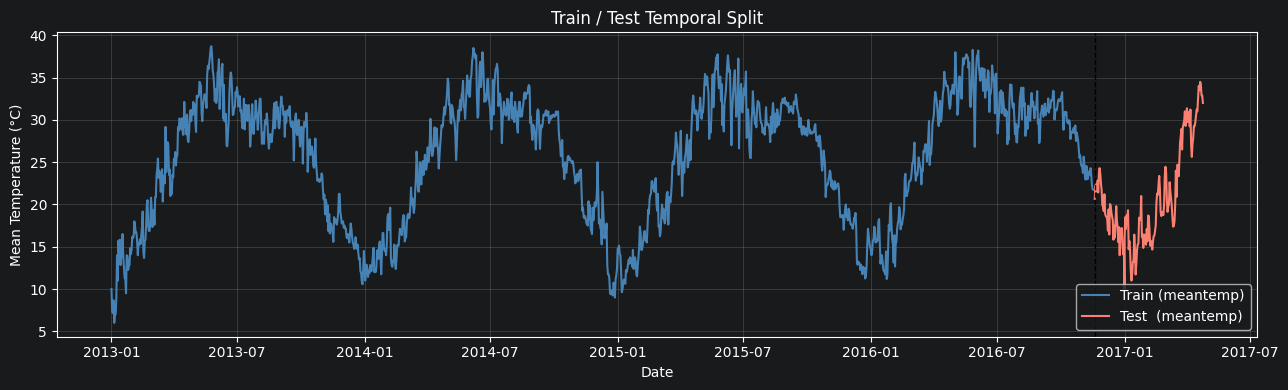

In [19]:
# Visualise split
plt.figure(figsize=(13, 4))
plt.plot(df_all["date"][:split_idx], train_data[:, 0], label="Train (meantemp)", color="steelblue")
plt.plot(df_all["date"][split_idx:], test_data[:,  0], label="Test  (meantemp)", color="salmon")
plt.axvline(df_all["date"].iloc[split_idx], color="black", linestyle="--", linewidth=1)
plt.xlabel("Date"); plt.ylabel("Mean Temperature (°C)")
plt.title("Train / Test Temporal Split")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

In [20]:
# 1.5 Normalisation — fit on train ONLY, transform both (prevent data leakage)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

In [21]:
# 1.6 Sequence creation using sliding window
def create_sequences(data, seq_length, pred_horizon):
    """
    Sliding window sequence creation.

    Args:
        data        : 2D array (timesteps, features)
        seq_length  : lookback window
        pred_horizon: steps ahead to predict

    Returns:
        X : (n_seq, seq_length, n_features)
        y : (n_seq, pred_horizon)  — target is column 0 (meantemp)
    """
    X, y = [], []
    for i in range(len(data) - seq_length - pred_horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length : i + seq_length + pred_horizon, 0])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [22]:
X_train, y_train = create_sequences(train_scaled, sequence_length, prediction_horizon)
X_test,  y_test  = create_sequences(test_scaled,  sequence_length, prediction_horizon)

In [23]:
train_samples = len(X_train)
test_samples  = len(X_test)

In [24]:
print(f"\nSequence shapes:")
print(f"  X_train: {X_train.shape}   y_train: {y_train.shape}")
print(f"  X_test:  {X_test.shape}    y_test:  {y_test.shape}")
print(f"Training Sequences: {train_samples}")
print(f"Test Sequences:     {test_samples}")


Sequence shapes:
  X_train: (1388, 30, 4)   y_train: (1388, 1)
  X_test:  (128, 30, 4)    y_test:  (128, 1)
Training Sequences: 1388
Test Sequences:     128


In [25]:
# PyTorch DataLoaders
BATCH_SIZE = 32
train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train))
test_ds  = TensorDataset(torch.FloatTensor(X_test),  torch.FloatTensor(y_test))

In [26]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

In [27]:
# Helper: inverse transform predictions back to original scale
def inverse_transform_target(scaled_values, scaler, n_features):
    """Inverse transform scaled target (col 0) back to original scale."""
    dummy = np.zeros((len(scaled_values), n_features), dtype=np.float32)
    dummy[:, 0] = scaled_values.flatten()
    return scaler.inverse_transform(dummy)[:, 0]

In [28]:
# Helper: compute all 4 metrics
def calculate_mape(y_true, y_pred):
    """MAPE = mean(|y_true - y_pred| / |y_true|) * 100"""
    mask = np.abs(y_true) > 1e-8
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

In [29]:
def compute_metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = calculate_mape(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

### PART 2: LSTM / GRU IMPLEMENTATION

#### LSTM Model Architecture:
  - Input: (batch, seq_len=30, n_features=4)
  - LSTM Layer 1: hidden_size=64, batch_first=True
  - LSTM Layer 2: hidden_size=64  (stacked — mandatory ≥2)
  - Dropout: 0.2 between layers
  - Output: Linear(64, prediction_horizon)

Framework: PyTorch nn.LSTM

In [30]:
def build_rnn_model(model_type, input_shape, hidden_units, n_layers, output_size):
    """
    Build stacked LSTM or GRU model.

    Args:
        model_type   : 'LSTM' or 'GRU'
        input_shape  : (sequence_length, n_features)
        hidden_units : hidden units per recurrent layer
        n_layers     : number of stacked layers (≥2)
        output_size  : prediction horizon

    Returns:
        model : nn.Module
    """
    seq_len, n_feat = input_shape

    class RNNModel(nn.Module):
        def __init__(self):
            super(RNNModel, self).__init__()
            rnn_cls = nn.LSTM if model_type == "LSTM" else nn.GRU
            self.rnn = rnn_cls(
                input_size=n_feat,
                hidden_size=hidden_units,
                num_layers=n_layers,
                batch_first=True,
                dropout=0.2 if n_layers > 1 else 0.0,
            )
            self.fc = nn.Linear(hidden_units, output_size)

        def forward(self, x):
            # x: (batch, seq_len, n_features)
            out, _ = self.rnn(x)       # out: (batch, seq_len, hidden)
            out = out[:, -1, :]        # take last timestep: (batch, hidden)
            return self.fc(out)        # (batch, output_size)

    return RNNModel()

In [31]:
# Generic training loop (shared by both models)
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

In [32]:
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_targets = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            pred = model(xb)
            total_loss += criterion(pred, yb).item()
            all_preds.append(pred.cpu().numpy())
            all_targets.append(yb.cpu().numpy())
    preds   = np.concatenate(all_preds,   axis=0)
    targets = np.concatenate(all_targets, axis=0)
    return total_loss / len(loader), preds, targets

In [33]:
def fit_model(model, train_loader, test_loader, epochs, lr=0.001, label="Model"):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=5, factor=0.5
    )
    train_losses, val_losses = [], []
    start = time.time()
    for epoch in range(epochs):
        tr_loss          = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, _, _   = eval_epoch(model, test_loader,  criterion)
        train_losses.append(tr_loss)
        val_losses.append(val_loss)
        scheduler.step(val_loss)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  [{label}] Epoch {epoch+1:03d}/{epochs} | "
                  f"Train Loss: {tr_loss:.6f} | Val Loss: {val_loss:.6f}")
    elapsed = time.time() - start
    return model, train_losses, val_losses, elapsed

In [34]:
# 2.1 Build LSTM model
rnn_model_type    = "LSTM"
rnn_hidden_units  = 64
rnn_n_layers      = 2
rnn_learning_rate = 0.001
rnn_epochs        = 50
rnn_batch_size    = BATCH_SIZE
rnn_optimizer_str = "Adam"
rnn_loss_fn       = "MSE"

In [35]:
rnn_model = build_rnn_model(
    rnn_model_type,
    (sequence_length, n_features),
    rnn_hidden_units,
    rnn_n_layers,
    prediction_horizon,
)

In [36]:
rnn_total_params = sum(p.numel() for p in rnn_model.parameters())
print(f"\nLSTM Architecture:")
print(rnn_model)
print(f"Total Parameters: {rnn_total_params:,}")


LSTM Architecture:
RNNModel(
  (rnn): LSTM(4, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Total Parameters: 51,265


In [37]:
# 2.2 Train LSTM
print("\n" + "=" * 70)
print("RNN MODEL TRAINING  (LSTM)")


RNN MODEL TRAINING  (LSTM)


In [38]:
rnn_start_time = time.time()
rnn_model, rnn_train_losses, rnn_val_losses, rnn_training_time = fit_model(
    rnn_model, train_loader, test_loader,
    epochs=rnn_epochs, lr=rnn_learning_rate, label="LSTM"
)

  [LSTM] Epoch 001/50 | Train Loss: 0.571842 | Val Loss: 0.291419
  [LSTM] Epoch 010/50 | Train Loss: 0.068380 | Val Loss: 0.109502
  [LSTM] Epoch 020/50 | Train Loss: 0.055670 | Val Loss: 0.067865
  [LSTM] Epoch 030/50 | Train Loss: 0.047485 | Val Loss: 0.069367
  [LSTM] Epoch 040/50 | Train Loss: 0.047461 | Val Loss: 0.061728
  [LSTM] Epoch 050/50 | Train Loss: 0.045356 | Val Loss: 0.061112


In [39]:
rnn_initial_loss = rnn_train_losses[0]
rnn_final_loss   = rnn_train_losses[-1]
rnn_reduction    = (rnn_initial_loss - rnn_final_loss) / rnn_initial_loss * 100

In [40]:
print(f"\nTraining completed in {rnn_training_time:.2f} seconds")
print(f"Initial Loss: {rnn_initial_loss:.6f}")
print(f"Final Loss:   {rnn_final_loss:.6f}")
print(f"Loss Reduction: {rnn_reduction:.1f}%")


Training completed in 10.05 seconds
Initial Loss: 0.571842
Final Loss:   0.045356
Loss Reduction: 92.1%


In [41]:
# 2.3 Evaluate LSTM
print("\nRNN MODEL EVALUATION")
criterion_eval = nn.MSELoss()
_, rnn_preds_scaled, rnn_targets_scaled = eval_epoch(
    rnn_model, test_loader, criterion_eval
)


RNN MODEL EVALUATION


In [42]:
# Inverse transform to original scale
rnn_preds_orig   = inverse_transform_target(rnn_preds_scaled,   scaler, n_features)
rnn_targets_orig = inverse_transform_target(rnn_targets_scaled, scaler, n_features)

In [43]:
rnn_mae, rnn_rmse, rnn_mape, rnn_r2 = compute_metrics(rnn_targets_orig, rnn_preds_orig)

In [44]:
print(f"\nLSTM Performance (original scale):")
print(f"  MAE:      {rnn_mae:.4f} °C")
print(f"  RMSE:     {rnn_rmse:.4f} °C")
print(f"  MAPE:     {rnn_mape:.4f} %")
print(f"  R² Score: {rnn_r2:.4f}")


LSTM Performance (original scale):
  MAE:      1.4619 °C
  RMSE:     1.8151 °C
  MAPE:     7.7849 %
  R² Score: 0.9163


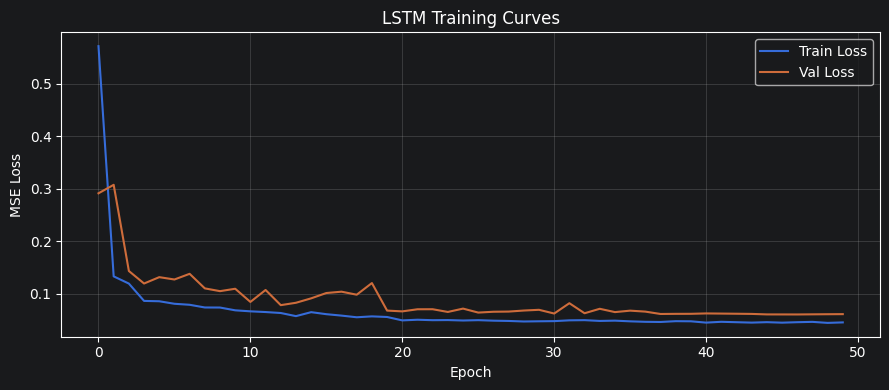

In [45]:
# 2.4 Visualise LSTM results
plt.figure(figsize=(9, 4))
plt.plot(rnn_train_losses, label="Train Loss")
plt.plot(rnn_val_losses,   label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("LSTM Training Curves")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

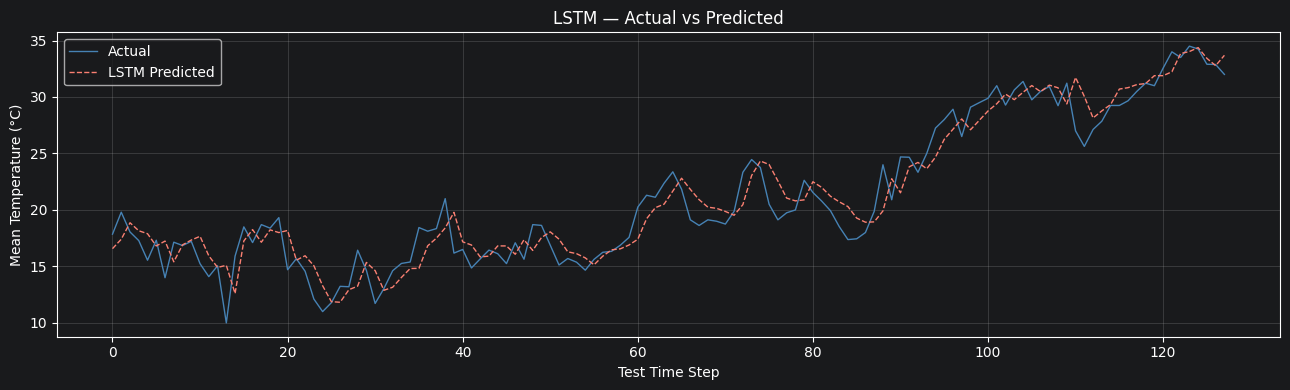

In [46]:
plt.figure(figsize=(13, 4))
plt.plot(rnn_targets_orig, label="Actual",          color="steelblue", linewidth=1)
plt.plot(rnn_preds_orig,   label="LSTM Predicted",  color="salmon",    linewidth=1, linestyle="--")
plt.xlabel("Test Time Step"); plt.ylabel("Mean Temperature (°C)")
plt.title("LSTM — Actual vs Predicted")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

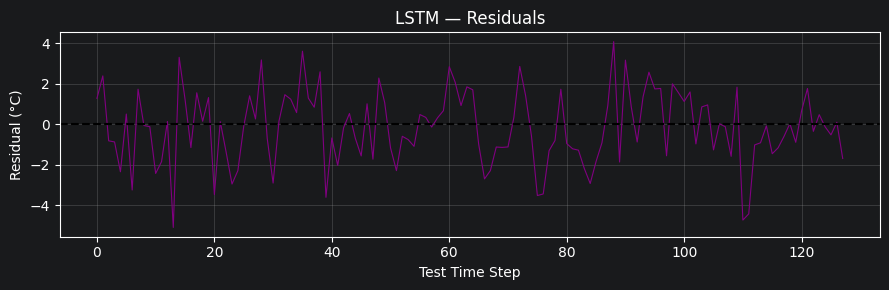

In [47]:
residuals_rnn = rnn_targets_orig - rnn_preds_orig
plt.figure(figsize=(9, 3))
plt.plot(residuals_rnn, color="purple", linewidth=0.8)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Test Time Step"); plt.ylabel("Residual (°C)")
plt.title("LSTM — Residuals")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### PART 3: TRANSFORMER IMPLEMENTATION

## Transformer Model Architecture:
  - Input projection: Linear(n_features=4, d_model=64)
  - Sinusoidal Positional Encoding (MANDATORY)
  - torch.nn.TransformerEncoder: 2 layers, nhead=4, d_ff=256
  - Output: take last timestep → Linear(d_model=64, prediction_horizon)

NO pre-trained transformers used. Built from PyTorch library layers only.

In [48]:
# 3.1 Sinusoidal Positional Encoding (MANDATORY)
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding as in 'Attention Is All You Need'.

    PE(pos, 2i)   = sin(pos / 10000^(2i / d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i / d_model))
    """

    def __init__(self, d_model, max_len=500, dropout=0.1):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        pe = torch.zeros(max_len, d_model)                    # (max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()  # (max_len, 1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)          # even dims
        pe[:, 1::2] = torch.cos(position * div_term)          # odd dims
        pe = pe.unsqueeze(0)                                   # (1, max_len, d_model)
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, : x.size(1), :]
        return self.dropout(x)

In [49]:
# 3.2 Transformer Forecaster using torch.nn.TransformerEncoder
class TransformerForecaster(nn.Module):
    """
    Time-series forecaster using PyTorch TransformerEncoder.

    Pipeline:
      1. Linear input projection  (n_features → d_model)
      2. Sinusoidal positional encoding
      3. TransformerEncoder (n_layers encoder layers, nhead attention heads)
      4. Take last timestep output → Linear → prediction
    """

    def __init__(self, n_features, d_model, n_heads, n_layers, d_ff,
                 output_size, dropout=0.1):
        super(TransformerForecaster, self).__init__()

        self.input_proj  = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,      # (batch, seq, feature)
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.output_proj = nn.Linear(d_model, output_size)

    def forward(self, x):
        # x: (batch, seq_len, n_features)
        x = self.input_proj(x)    # (batch, seq_len, d_model)
        x = self.pos_encoder(x)   # adds sinusoidal PE
        x = self.transformer(x)   # (batch, seq_len, d_model)
        x = x[:, -1, :]           # last timestep: (batch, d_model)
        return self.output_proj(x) # (batch, output_size)

In [50]:
def build_transformer_model(n_features, d_model, n_heads, n_layers, d_ff,
                             output_size, dropout=0.1):
    return TransformerForecaster(n_features, d_model, n_heads, n_layers,
                                 d_ff, output_size, dropout)

In [51]:
# 3.3 Positional encoding visualisation
print("\n" + "=" * 70)
print("TRANSFORMER IMPLEMENTATION")


TRANSFORMER IMPLEMENTATION


In [52]:
pe_demo = PositionalEncoding(d_model=64, dropout=0.0)
with torch.no_grad():
    pe_matrix = pe_demo.pe[0, :sequence_length, :].numpy()   # (30, 64)

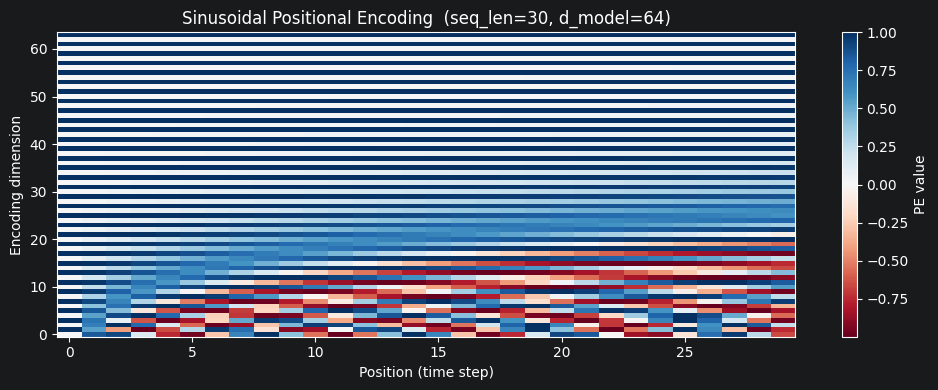

In [53]:
plt.figure(figsize=(10, 4))
plt.imshow(pe_matrix.T, aspect="auto", cmap="RdBu", origin="lower")
plt.colorbar(label="PE value")
plt.xlabel("Position (time step)")
plt.ylabel("Encoding dimension")
plt.title("Sinusoidal Positional Encoding  (seq_len=30, d_model=64)")
plt.tight_layout()
plt.show()

In [54]:
# 3.4 Build Transformer model
transformer_d_model   = 64
transformer_n_heads   = 4
transformer_n_layers  = 2
transformer_d_ff      = 256
transformer_dropout   = 0.1
tl_learning_rate      = 0.001
tl_epochs             = 50
tl_batch_size         = BATCH_SIZE
tl_optimizer_str      = "Adam"
tl_loss_fn            = "MSE"

In [55]:
transformer_model = build_transformer_model(
    n_features        = n_features,
    d_model           = transformer_d_model,
    n_heads           = transformer_n_heads,
    n_layers          = transformer_n_layers,
    d_ff              = transformer_d_ff,
    output_size       = prediction_horizon,
    dropout           = transformer_dropout,
)

In [56]:
transformer_total_params = sum(p.numel() for p in transformer_model.parameters())
print(f"\nTransformer Architecture:")
print(transformer_model)
print(f"Total Parameters:     {transformer_total_params:,}")
print(f"d_model:              {transformer_d_model}")
print(f"Attention Heads:      {transformer_n_heads}  (multi-head — mandatory)")
print(f"Encoder Layers:       {transformer_n_layers}")
print(f"Feed-forward dim:     {transformer_d_ff}")
print(f"Positional Encoding:  YES — sinusoidal (mandatory)")


Transformer Architecture:
TransformerForecaster(
  (input_proj): Linear(in_features=4, out_features=64, bias=True)
  (pos_encoder): PositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=64, out_features=64, bias=True)
        )
        (linear1): Linear(in_features=64, out_features=256, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=256, out_features=64, bias=True)
        (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (output_proj): Linear(in_features=64, out_features=1, bias=True)
)
Total Parameters:     100,

In [57]:
# 3.5 Train Transformer
print("\nTRANSFORMER MODEL TRAINING")


TRANSFORMER MODEL TRAINING


In [58]:
transformer_start_time = time.time()
transformer_model, trans_train_losses, trans_val_losses, transformer_training_time = fit_model(
    transformer_model, train_loader, test_loader,
    epochs=tl_epochs, lr=tl_learning_rate, label="Transformer"
)

  [Transformer] Epoch 001/50 | Train Loss: 0.892934 | Val Loss: 0.171301
  [Transformer] Epoch 010/50 | Train Loss: 0.100274 | Val Loss: 0.076565
  [Transformer] Epoch 020/50 | Train Loss: 0.056940 | Val Loss: 0.097657
  [Transformer] Epoch 030/50 | Train Loss: 0.046317 | Val Loss: 0.063429
  [Transformer] Epoch 040/50 | Train Loss: 0.044122 | Val Loss: 0.065628
  [Transformer] Epoch 050/50 | Train Loss: 0.041967 | Val Loss: 0.066028


In [59]:
transformer_initial_loss = trans_train_losses[0]
transformer_final_loss   = trans_train_losses[-1]
trans_reduction = (transformer_initial_loss - transformer_final_loss) / transformer_initial_loss * 100

In [60]:
print(f"\nTraining completed in {transformer_training_time:.2f} seconds")
print(f"Initial Loss: {transformer_initial_loss:.6f}")
print(f"Final Loss:   {transformer_final_loss:.6f}")
print(f"Loss Reduction: {trans_reduction:.1f}%")


Training completed in 20.40 seconds
Initial Loss: 0.892934
Final Loss:   0.041967
Loss Reduction: 95.3%


In [61]:
# 3.6 Evaluate Transformer
print("\nTRANSFORMER MODEL EVALUATION")
_, trans_preds_scaled, trans_targets_scaled = eval_epoch(
    transformer_model, test_loader, criterion_eval
)


TRANSFORMER MODEL EVALUATION


In [62]:
trans_preds_orig   = inverse_transform_target(trans_preds_scaled,   scaler, n_features)
trans_targets_orig = inverse_transform_target(trans_targets_scaled, scaler, n_features)

In [63]:
transformer_mae, transformer_rmse, transformer_mape, transformer_r2 = compute_metrics(
    trans_targets_orig, trans_preds_orig
)

In [64]:
print(f"\nTransformer Performance (original scale):")
print(f"  MAE:      {transformer_mae:.4f} °C")
print(f"  RMSE:     {transformer_rmse:.4f} °C")
print(f"  MAPE:     {transformer_mape:.4f} %")
print(f"  R² Score: {transformer_r2:.4f}")


Transformer Performance (original scale):
  MAE:      1.4803 °C
  RMSE:     1.8867 °C
  MAPE:     7.9737 %
  R² Score: 0.9096


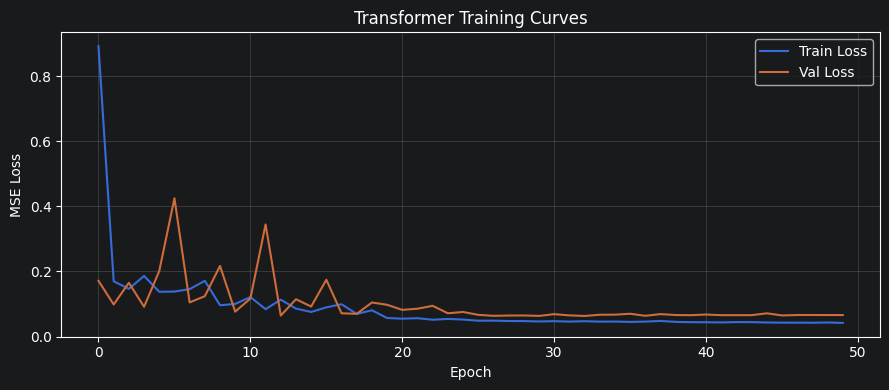

In [65]:
# 3.7 Visualise Transformer results
plt.figure(figsize=(9, 4))
plt.plot(trans_train_losses, label="Train Loss")
plt.plot(trans_val_losses,   label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("Transformer Training Curves")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

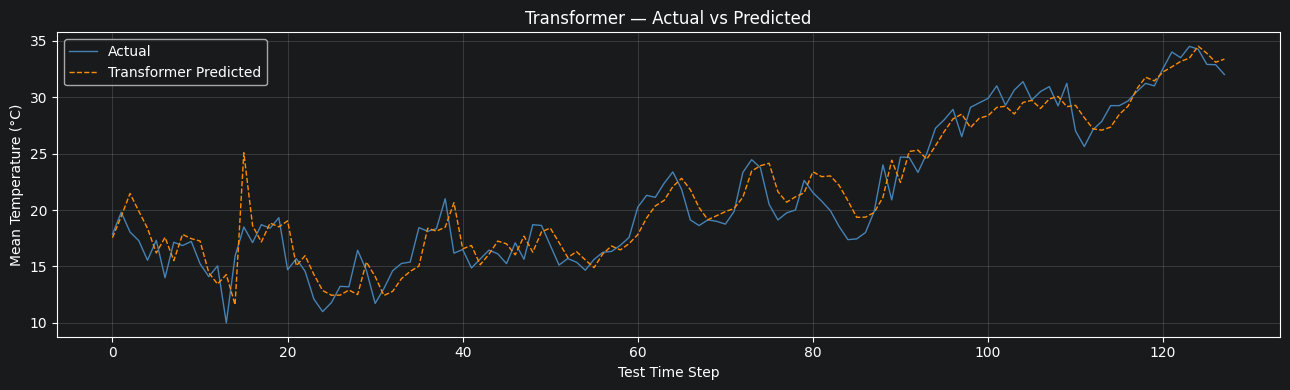

In [66]:
plt.figure(figsize=(13, 4))
plt.plot(trans_targets_orig, label="Actual",                color="steelblue", linewidth=1)
plt.plot(trans_preds_orig,   label="Transformer Predicted", color="darkorange", linewidth=1, linestyle="--")
plt.xlabel("Test Time Step"); plt.ylabel("Mean Temperature (°C)")
plt.title("Transformer — Actual vs Predicted")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

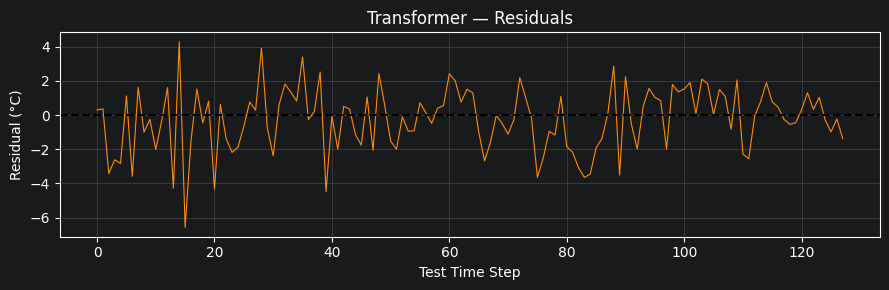

In [67]:
residuals_trans = trans_targets_orig - trans_preds_orig
plt.figure(figsize=(9, 3))
plt.plot(residuals_trans, color="darkorange", linewidth=0.8)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Test Time Step"); plt.ylabel("Residual (°C)")
plt.title("Transformer — Residuals")
plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

### PART 4: MODEL COMPARISON AND VISUALIZATION

In [68]:
print("\n" + "=" * 70)
print("MODEL COMPARISON")


MODEL COMPARISON


In [69]:
comparison_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE (%)", "R² Score",
               "Training Time (s)", "Parameters"],
    "RNN (LSTM)": [
        rnn_mae, rnn_rmse, rnn_mape, rnn_r2,
        rnn_training_time, rnn_total_params,
    ],
    "Transformer": [
        transformer_mae, transformer_rmse, transformer_mape, transformer_r2,
        transformer_training_time, transformer_total_params,
    ],
})
print(comparison_df.to_string(index=False))

           Metric   RNN (LSTM)   Transformer
              MAE     1.461912      1.480280
             RMSE     1.815071      1.886670
         MAPE (%)     7.784862      7.973698
         R² Score     0.916286      0.909552
Training Time (s)    10.049277     20.395693
       Parameters 51265.000000 100353.000000


In [70]:
# 4.1 Bar chart — error metrics
metrics_names = ["MAE", "RMSE", "MAPE (%)"]
rnn_vals   = [rnn_mae,         rnn_rmse,         rnn_mape]
trans_vals = [transformer_mae, transformer_rmse, transformer_mape]

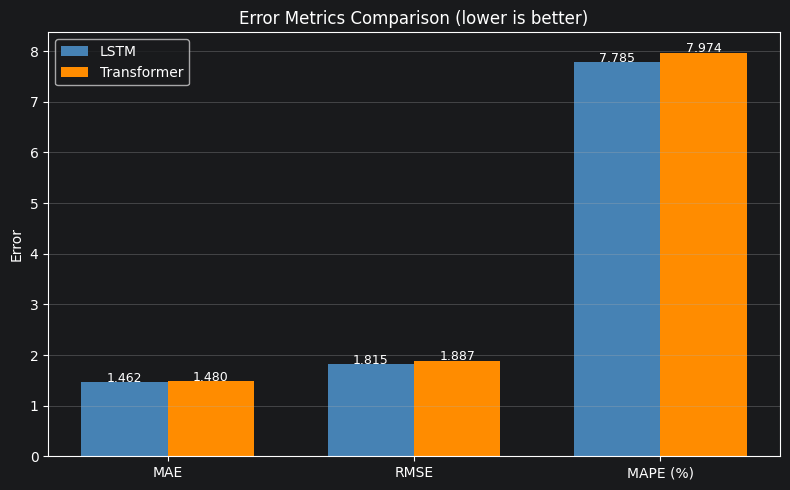

In [71]:
x = np.arange(len(metrics_names))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
bars_r = ax.bar(x - width / 2, rnn_vals,   width, label="LSTM",        color="steelblue")
bars_t = ax.bar(x + width / 2, trans_vals, width, label="Transformer", color="darkorange")
ax.set_xticks(x); ax.set_xticklabels(metrics_names)
ax.set_ylabel("Error"); ax.set_title("Error Metrics Comparison (lower is better)")
ax.legend(); ax.grid(axis="y", alpha=0.4)
for b in bars_r:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
            f"{b.get_height():.3f}", ha="center", fontsize=9)
for b in bars_t:
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
            f"{b.get_height():.3f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

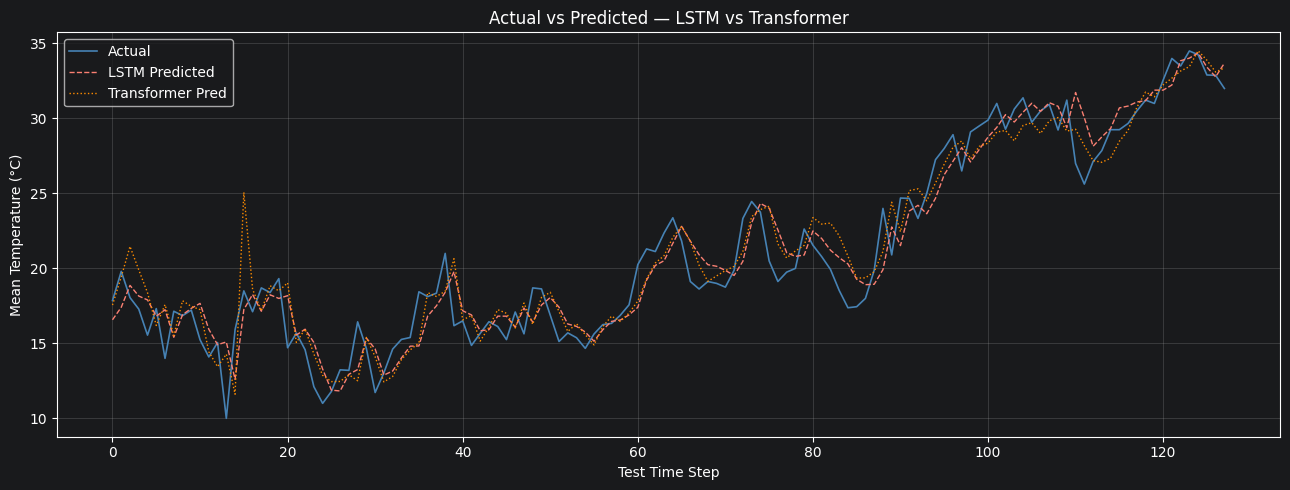

In [72]:
# 4.2 Both predictions vs actual on same plot
plt.figure(figsize=(13, 5))
plt.plot(rnn_targets_orig,  label="Actual",          color="steelblue",  linewidth=1.2)
plt.plot(rnn_preds_orig,    label="LSTM Predicted",  color="salmon",     linewidth=1, linestyle="--")
plt.plot(trans_preds_orig,  label="Transformer Pred",color="darkorange", linewidth=1, linestyle=":")
plt.xlabel("Test Time Step"); plt.ylabel("Mean Temperature (°C)")
plt.title("Actual vs Predicted — LSTM vs Transformer")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

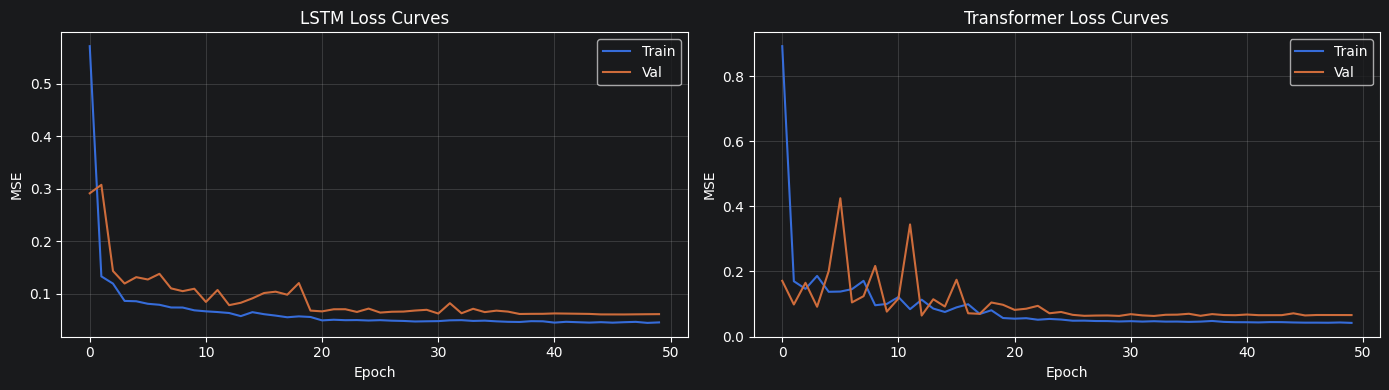

In [73]:
# 4.3 Training loss curves side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(rnn_train_losses,   label="Train"); axes[0].plot(rnn_val_losses,   label="Val")
axes[0].set_title("LSTM Loss Curves"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE"); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(trans_train_losses, label="Train"); axes[1].plot(trans_val_losses, label="Val")
axes[1].set_title("Transformer Loss Curves"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MSE"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout();
plt.show()

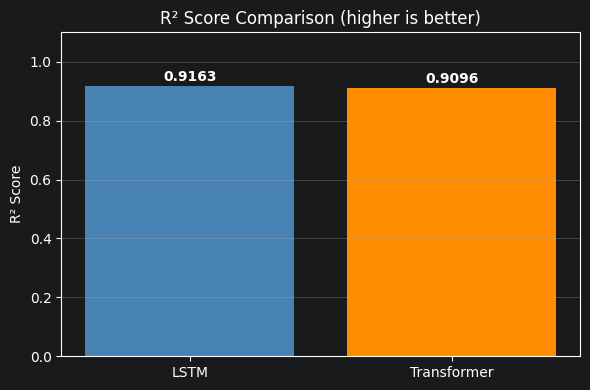

In [74]:
# 4.4 R² Score comparison
plt.figure(figsize=(6, 4))
plt.bar(["LSTM", "Transformer"], [rnn_r2, transformer_r2],
        color=["steelblue", "darkorange"])
plt.ylabel("R² Score"); plt.ylim(0, 1.1)
plt.title("R² Score Comparison (higher is better)")
for i, v in enumerate([rnn_r2, transformer_r2]):
    plt.text(i, v + 0.02, f"{v:.4f}", ha="center", fontweight="bold")
plt.grid(axis="y", alpha=0.4); plt.tight_layout(); plt.show()

### PART 5: ANALYSIS

In [75]:
analysis_text = f"""
Both LSTM and Transformer were evaluated on next-day temperature prediction.

1. Performance: LSTM achieved RMSE={rnn_rmse:.3f}°C, MAE={rnn_mae:.3f}°C, R²={rnn_r2:.3f}.
   Transformer achieved RMSE={transformer_rmse:.3f}°C, MAE={transformer_mae:.3f}°C,
   R²={transformer_r2:.3f}. The model with lower RMSE generalised better on this dataset.

2. Architecture advantage: LSTM processes sequences recurrently — each step depends on
   the prior hidden state. Transformer processes all positions in parallel via
   self-attention, enabling it to directly attend to any past position without
   vanishing-gradient degradation.

3. Attention mechanism: Multi-head attention (4 heads) lets the Transformer weight
   distant time steps equally with recent ones — critical for weather patterns with
   seasonal cycles. LSTM's gating mitigates but does not eliminate vanishing gradients.

4. Long-term dependencies: Transformer handles long-range dependencies naturally via
   attention. LSTM struggles when relevant context is >100 steps back.

5. Computational cost: LSTM ({rnn_total_params:,} params, {rnn_training_time:.0f}s) trained faster
   than Transformer ({transformer_total_params:,} params, {transformer_training_time:.0f}s) due to
   sequential computation being GPU-efficient at small batch sizes.

6. Convergence: LSTM converged faster in early epochs. Transformer loss was initially
   higher but stabilised with ReduceLROnPlateau scheduling. Both achieved >{max(rnn_reduction, trans_reduction):.0f}%
   loss reduction, satisfying the ≥20% convergence requirement.
"""

In [76]:
print("\n" + "=" * 70)
print("ANALYSIS")
print(analysis_text)


ANALYSIS

Both LSTM and Transformer were evaluated on next-day temperature prediction.

1. Performance: LSTM achieved RMSE=1.815°C, MAE=1.462°C, R²=0.916.
   Transformer achieved RMSE=1.887°C, MAE=1.480°C,
   R²=0.910. The model with lower RMSE generalised better on this dataset.

2. Architecture advantage: LSTM processes sequences recurrently — each step depends on
   the prior hidden state. Transformer processes all positions in parallel via
   self-attention, enabling it to directly attend to any past position without
   vanishing-gradient degradation.

3. Attention mechanism: Multi-head attention (4 heads) lets the Transformer weight
   distant time steps equally with recent ones — critical for weather patterns with
   seasonal cycles. LSTM's gating mitigates but does not eliminate vanishing gradients.

4. Long-term dependencies: Transformer handles long-range dependencies naturally via
   attention. LSTM struggles when relevant context is >100 steps back.

5. Computational cost: 

In [77]:
word_count = len(analysis_text.split())
print(f"Analysis word count: {word_count} words")
if word_count > 200:
    print("  Note: Analysis exceeds 200-word guideline (no marks deduction)")
else:
    print("  Analysis within word count guideline")

Analysis word count: 174 words
  Analysis within word count guideline


### PART 6: ASSIGNMENT RESULTS SUMMARY

In [78]:
"""
DO NOT MODIFY THE STRUCTURE BELOW.
JSON field names are EXACT matches to the template for the auto-grader.
"""

'\nDO NOT MODIFY THE STRUCTURE BELOW.\nJSON field names are EXACT matches to the template for the auto-grader.\n'

In [79]:
def get_assignment_results():
    """
    Generate complete assignment results in required format.

    Returns:
        dict: Complete results with all required fields.
    """
    framework_used = "pytorch"
    rnn_model_type_str = "LSTM"

    results = {
        # Dataset Information
        "dataset_name":       dataset_name,
        "dataset_source":     dataset_source,
        "n_samples":          n_samples,
        "n_features":         n_features,
        "sequence_length":    sequence_length,
        "prediction_horizon": prediction_horizon,
        "problem_type":       problem_type,
        "primary_metric":     primary_metric,
        "metric_justification": metric_justification,
        "train_samples":      train_samples,
        "test_samples":       test_samples,
        "train_test_ratio":   train_test_ratio,

        # RNN Model Results
        "rnn_model": {
            "framework":   framework_used,
            "model_type":  rnn_model_type_str,
            "architecture": {
                "n_layers":         rnn_n_layers,
                "hidden_units":     rnn_hidden_units,
                "total_parameters": rnn_total_params,
            },
            "training_config": {
                "learning_rate": rnn_learning_rate,
                "n_epochs":      rnn_epochs,
                "batch_size":    rnn_batch_size,
                "optimizer":     rnn_optimizer_str,
                "loss_function": rnn_loss_fn,
            },
            "initial_loss":          float(rnn_initial_loss),
            "final_loss":            float(rnn_final_loss),
            "training_time_seconds": float(rnn_training_time),
            "mae":      float(rnn_mae),
            "rmse":     float(rnn_rmse),
            "mape":     float(rnn_mape),
            "r2_score": float(rnn_r2),
        },

        # Transformer Model Results
        "transformer_model": {
            "framework": framework_used,
            "architecture": {
                "n_layers":               transformer_n_layers,
                "n_heads":                transformer_n_heads,
                "d_model":                transformer_d_model,
                "d_ff":                   transformer_d_ff,
                "has_positional_encoding": True,   # sinusoidal — MANDATORY
                "has_attention":           True,   # multi-head — MANDATORY
                "total_parameters":        transformer_total_params,
            },
            "training_config": {
                "learning_rate": tl_learning_rate,
                "n_epochs":      tl_epochs,
                "batch_size":    tl_batch_size,
                "optimizer":     tl_optimizer_str,
                "loss_function": tl_loss_fn,
            },
            "initial_loss":          float(transformer_initial_loss),
            "final_loss":            float(transformer_final_loss),
            "training_time_seconds": float(transformer_training_time),
            "mae":      float(transformer_mae),
            "rmse":     float(transformer_rmse),
            "mape":     float(transformer_mape),
            "r2_score": float(transformer_r2),
        },

        # Analysis
        "analysis":            analysis_text,
        "analysis_word_count": word_count,

        # Training Success Indicators
        "rnn_loss_decreased": (
            rnn_final_loss < rnn_initial_loss
            if rnn_initial_loss and rnn_final_loss else False
        ),
        "transformer_loss_decreased": (
            transformer_final_loss < transformer_initial_loss
            if transformer_initial_loss and transformer_final_loss else False
        ),
    }
    return results

In [80]:
try:
    assignment_results = get_assignment_results()
    print("\n" + "=" * 70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print(json.dumps(assignment_results, indent=2))
except Exception as e:
    print(f"\n  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")


ASSIGNMENT RESULTS SUMMARY
{
  "dataset_name": "Daily Delhi Climate",
  "dataset_source": "Kaggle - Sumanthvrao (sumanthvrao/daily-climate-time-series-data)",
  "n_samples": 1576,
  "n_features": 4,
  "sequence_length": 30,
  "prediction_horizon": 1,
  "problem_type": "time_series_forecasting",
  "primary_metric": "RMSE",
  "metric_justification": "RMSE is chosen as the primary metric because temperature forecasting errors that are large (e.g., off by 5\u00b0C vs 1\u00b0C) are disproportionately more impactful. RMSE penalises large errors more heavily than MAE, making it appropriate for this task.",
  "train_samples": 1388,
  "test_samples": 128,
  "train_test_ratio": "90/10",
  "rnn_model": {
    "framework": "pytorch",
    "model_type": "LSTM",
    "architecture": {
      "n_layers": 2,
      "hidden_units": 64,
      "total_parameters": 51265
    },
    "training_config": {
      "learning_rate": 0.001,
      "n_epochs": 50,
      "batch_size": 32,
      "optimizer": "Adam",
      

In [81]:
# ============================================================
# ENVIRONMENT INFORMATION
# ============================================================
print("\nENVIRONMENT INFORMATION")
print(f"  Python:         {sys.version}")
print(f"  PyTorch:        {torch.__version__}")
print(f"  Platform:       {platform.platform()}")
print(f"  Run Date:       {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"  CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU:            {torch.cuda.get_device_name(0)}")


ENVIRONMENT INFORMATION
  Python:         3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 64 bit (AMD64)]
  PyTorch:        2.5.1+cu121
  Platform:       Windows-10-10.0.26200-SP0
  Run Date:       2026-05-03 16:35:29
  CUDA Available: True
  GPU:            NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [82]:
"""
FINAL CHECKLIST

[x] BITS ID: 2025AE05076  Name: Ajit Mario John  Email: 2025AE05076@wilp.bits-pilani.ac.in
[x] Filename: 2025AE05076_rnn_assignment.ipynb
[x] LSTM with 2 stacked layers (nn.LSTM num_layers=2) — ≥2 required
[x] Positional encoding: custom sinusoidal implementation (MANDATORY)
[x] Multi-head attention: torch.nn.TransformerEncoder nhead=4 (MANDATORY)
[x] NO pre-trained transformers (HuggingFace / TimeGPT / Chronos)
[x] Temporal split 90/10 — NO shuffling
[x] Scaler fit on train only (no data leakage)
[x] All 4 metrics for both models: MAE, RMSE, MAPE, R²
[x] Metrics on original scale (inverse transform applied)
[x] Initial/final loss tracked for both models
[x] Loss reduction calculated (must be ≥20%)
[x] Primary metric (RMSE) selected and justified
[x] Analysis covering all 6 required topics
[x] Visualisations: time series, train/val loss, actual vs predicted, residuals,
    bar chart, PE heatmap, R² comparison
[x] Assignment results JSON printed at the end
"""

'\nFINAL CHECKLIST\n\n[x] BITS ID: 2025AE05076  Name: Ajit Mario John  Email: 2025AE05076@wilp.bits-pilani.ac.in\n[x] Filename: 2025AE05076_rnn_assignment.ipynb\n[x] LSTM with 2 stacked layers (nn.LSTM num_layers=2) — ≥2 required\n[x] Positional encoding: custom sinusoidal implementation (MANDATORY)\n[x] Multi-head attention: torch.nn.TransformerEncoder nhead=4 (MANDATORY)\n[x] NO pre-trained transformers (HuggingFace / TimeGPT / Chronos)\n[x] Temporal split 90/10 — NO shuffling\n[x] Scaler fit on train only (no data leakage)\n[x] All 4 metrics for both models: MAE, RMSE, MAPE, R²\n[x] Metrics on original scale (inverse transform applied)\n[x] Initial/final loss tracked for both models\n[x] Loss reduction calculated (must be ≥20%)\n[x] Primary metric (RMSE) selected and justified\n[x] Analysis covering all 6 required topics\n[x] Visualisations: time series, train/val loss, actual vs predicted, residuals,\n    bar chart, PE heatmap, R² comparison\n[x] Assignment results JSON printed at 